In [8]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns 
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

In [2]:
# Load the cleaned dataset (from Step 1)
columns = [
    "age", "sex", "cp", "trestbps", "chol",
    "fbs", "restecg", "thalach", "exang",
    "oldpeak", "slope", "ca", "thal", "target"
]

df = pd.read_csv("processed.cleveland.data",
                 names=columns, na_values="?")

In [3]:
df = df.dropna()

In [6]:
# Separate features & target
x = df.drop("target", axis=1)
y = df["target"]

# Standardize features
scaler = StandardScaler()
x_scaled = scaler.fit_transform(x)


In [9]:
# Apply PCA
pca = PCA()
x_pca = pca.fit_transform(x_scaled)

In [10]:
# Explained variance ratio
explained_variance = pca.explained_variance_ratio_
cumulative_variance = explained_variance.cumsum()

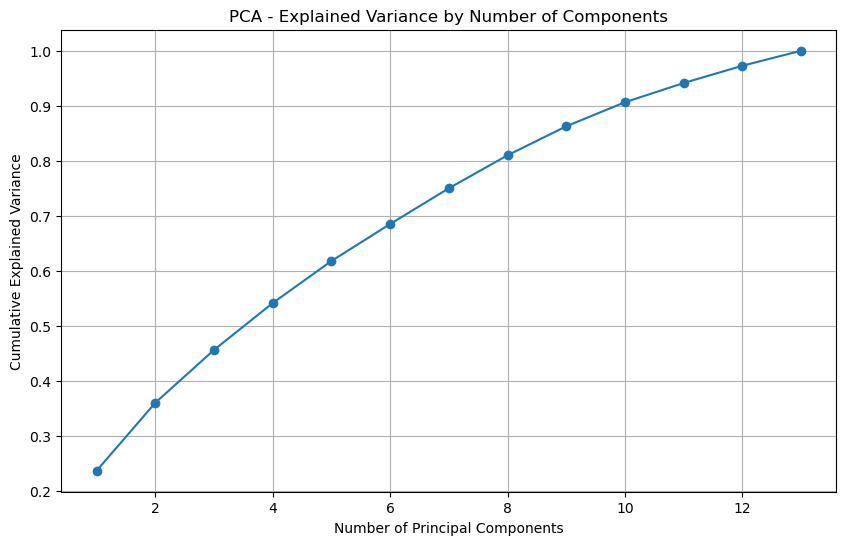

In [11]:
# Plot explained variance
plt.figure(figsize=(10,6))
plt.plot(range(1, len(explained_variance)+1), cumulative_variance, marker='o')
plt.xlabel("Number of Principal Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("PCA - Explained Variance by Number of Components")
plt.grid(True)
plt.show()